## Order Items data EDA

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
order_items = pd.read_csv("../../data/raw/olist_order_items_dataset.csv")

In [3]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [4]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [5]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


Axes(0.125,0.11;0.775x0.77)


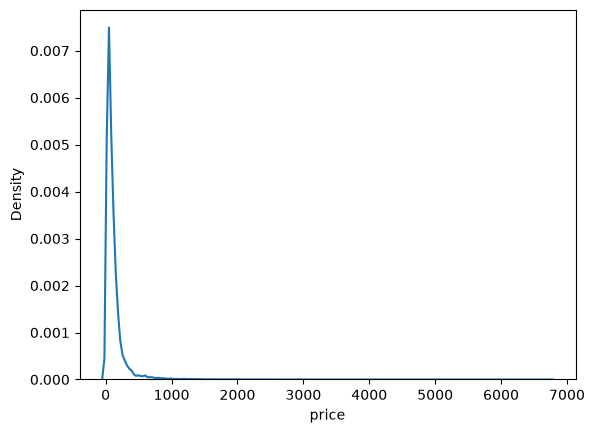

In [6]:
print(sns.kdeplot(data=order_items,x="price"))
plt.savefig("../../output/charts/order_item/price_densitykde.png", dpi=300, bbox_inches="tight")


Axes(0.125,0.11;0.775x0.77)


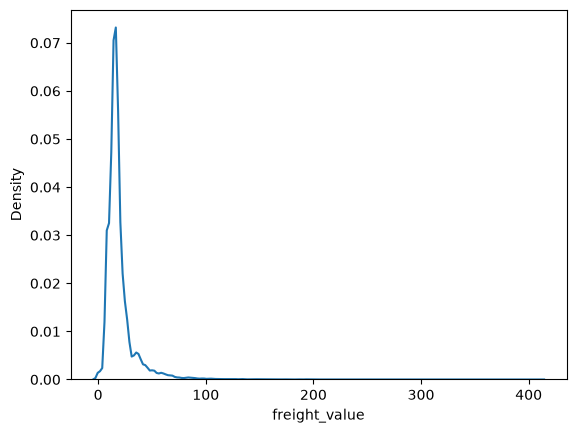

In [7]:
print(sns.kdeplot(data=order_items,x="freight_value"))
plt.savefig("../../output/charts/order_item/freight_value_kde.png", dpi=300, bbox_inches="tight")
#freight value is nothing but shipping cost 

In [8]:
order_items["total_price"] = order_items["price"]+order_items["freight_value"]

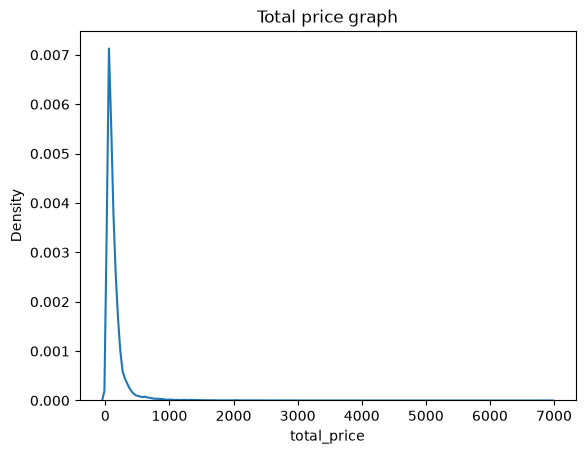

In [9]:
sns.kdeplot(data=order_items,x="total_price")
plt.title("Total price graph")
plt.show()

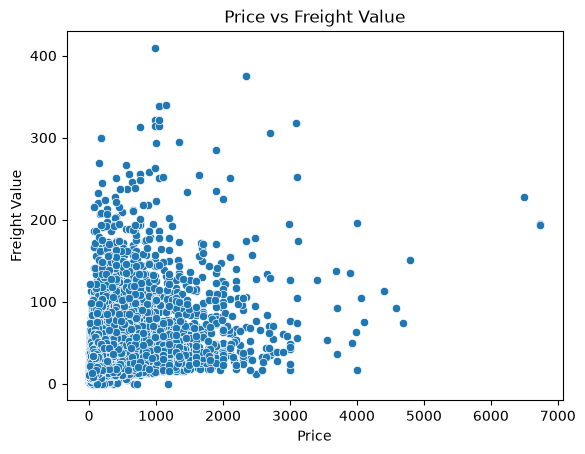

In [10]:
sns.scatterplot(
    data=order_items,
    x="price",
    y="freight_value"
)

plt.title("Price vs Freight Value")
plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.show()

In [11]:
order_items["seller_id"].duplicated().sum()

np.int64(109555)

In [12]:
order_items["seller_id"].nunique() #total number of vendors

3095

In [13]:
top_vendor = order_items["seller_id"].value_counts().head(15)

In [14]:
top_vendor

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
4869f7a5dfa277a7dca6462dcf3b52b2    1156
3d871de0142ce09b7081e2b9d1733cb1    1147
8b321bb669392f5163d04c59e235e066    1018
cca3071e3e9bb7d12640c9fbe2301306     830
620c87c171fb2a6dd6e8bb4dec959fc6     798
Name: count, dtype: int64

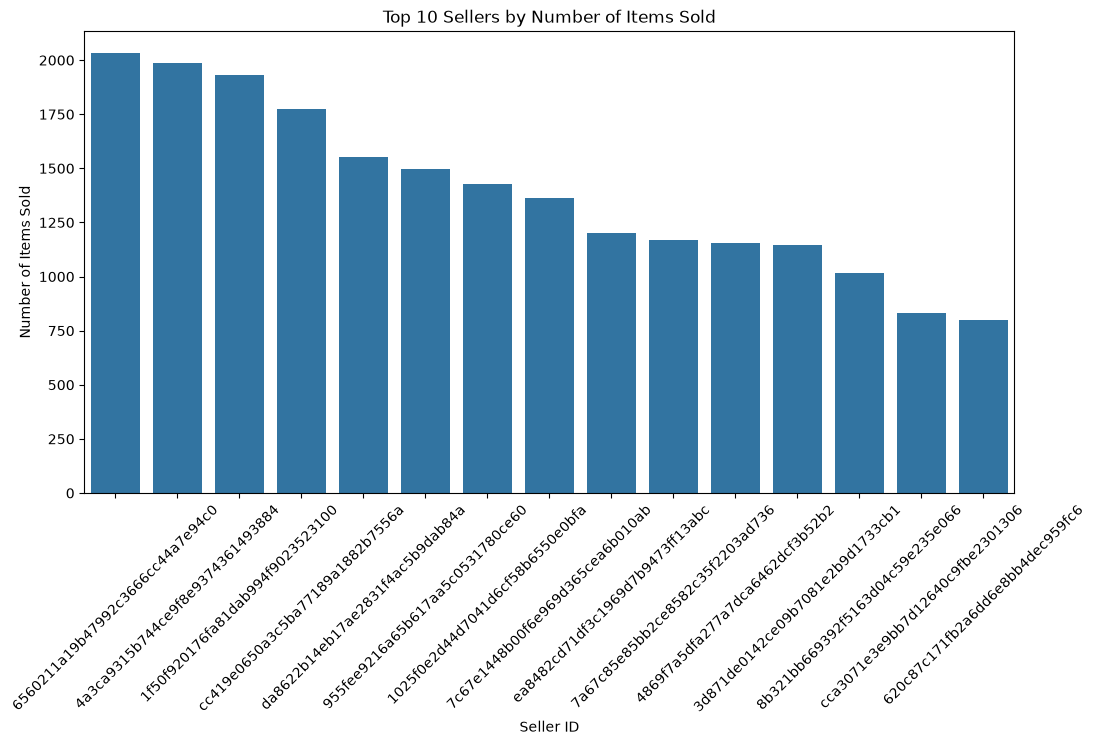

In [15]:

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_vendor.index,
    y=top_vendor.values
)

plt.xticks(rotation=45)
plt.xlabel("Seller ID")
plt.ylabel("Number of Items Sold")
plt.title("Top 10 Sellers by Number of Items Sold")
plt.savefig("../../output/charts/order_item/top_vendor_barplot.png", dpi=300)
plt.show()



In [41]:
order_items_count = order_items["order_item_id"].value_counts()
order_items_count

order_item_id
1     98666
2      9803
3      2287
4       965
5       460
6       256
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: count, dtype: int64

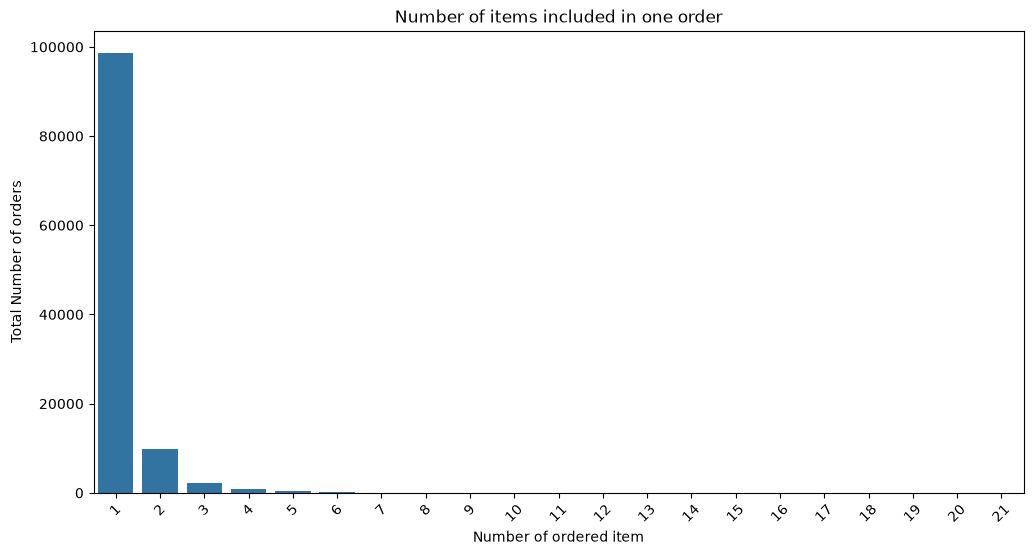

In [17]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=order_items_count.index,
    y=order_items_count.values
)

plt.xticks(rotation=45)
plt.xlabel("Number of ordered item")
plt.ylabel("Total Number of orders")
plt.title("Number of items included in one order")
plt.savefig("../../output/charts/order_item/quantity_of_product_per_order.png", dpi=300)
plt.show()


In [18]:
product_count = order_items["product_id"].value_counts().head(20)
product_count

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
2b4609f8948be18874494203496bc318    260
7c1bd920dbdf22470b68bde975dd3ccf    231
a62e25e09e05e6faf31d90c6ec1aa3d1    226
5a848e4ab52fd5445cdc07aab1c40e48    197
bb50f2e236e5eea0100680137654686c    195
e0d64dcfaa3b6db5c54ca298ae101d05    194
e53e557d5a159f5aa2c5e995dfdf244b    183
42a2c92a0979a949ca4ea89ec5c7b934    183
b532349fe46b38fbc7bb3914c1bdae07    169
35afc973633aaeb6b877ff57b2793310    165
Name: count, dtype: int64

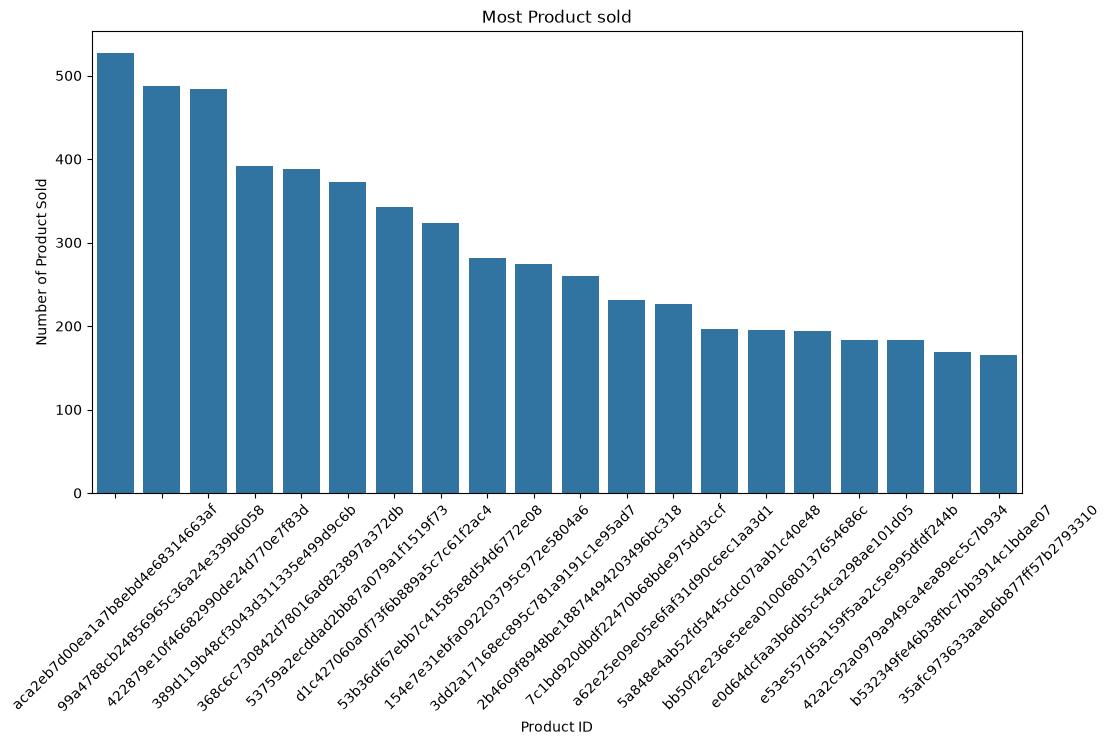

In [19]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=product_count.index,
    y=product_count.values
)

plt.xticks(rotation=45)
plt.xlabel("Product ID")
plt.ylabel("Number of Product Sold")
plt.title("Most Product sold")
plt.savefig("../../output/charts/order_item/most-sold-product.png", dpi=300)
plt.show()


In [21]:
order_items["shipping_limit_date"].describe()

count                  112650
unique                  93318
top       2018-03-01 02:50:48
freq                       21
Name: shipping_limit_date, dtype: object

In [23]:
print("Min Date: ",order_items["shipping_limit_date"].min())
print("Max Date: ",order_items["shipping_limit_date"].max())


Min Date:  2016-09-19 00:15:34
Max Date:  2020-04-09 22:35:08


In [24]:
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

In [45]:
order_items["shipping_limit_date"].dt.to_period("Y").value_counts()

shipping_limit_date
2018    62511
2017    49765
2016      370
2020        4
Freq: Y-DEC, Name: count, dtype: int64

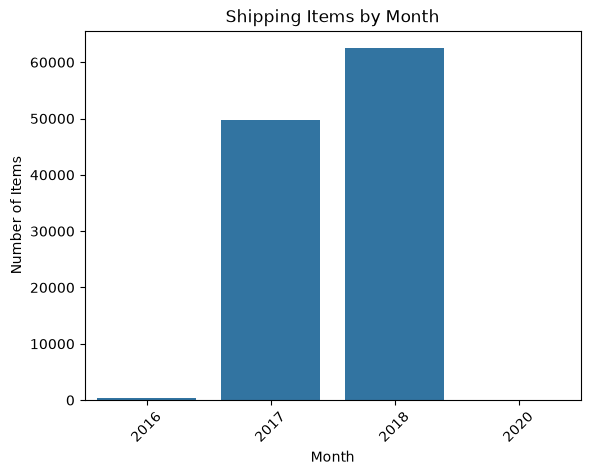

In [46]:
yearly_shipping = (
    order_items
    .groupby(order_items["shipping_limit_date"].dt.to_period("Y"))
    .size()
)

sns.barplot(
    x=yearly_shipping.index.astype(str),
    y=yearly_shipping.values
)

plt.xticks(rotation=45)
plt.title("Shipping Items by Month")
plt.xlabel("Month")
plt.ylabel("Number of Items")
plt.savefig("../../output/charts/order_item/shipping_by_year_barplot",dpi=300)
plt.show()

In [44]:
order_items["shipping_limit_date"].dt.to_period("M").value_counts().sort_index()

shipping_limit_date
2016-09       4
2016-10     365
2016-12       1
2017-01     681
2017-02    1866
2017-03    2751
2017-04    2364
2017-05    4150
2017-06    3801
2017-07    4116
2017-08    5042
2017-09    4724
2017-10    5189
2017-11    7355
2017-12    7726
2018-01    7492
2018-02    7375
2018-03    8759
2018-04    7637
2018-05    8765
2018-06    6897
2018-07    6672
2018-08    8815
2018-09      99
2020-02       2
2020-04       2
Freq: M, Name: count, dtype: int64

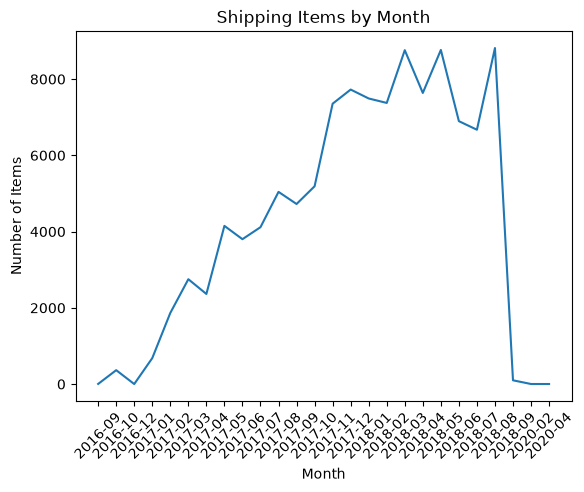

In [28]:
monthly_shipping = (
    order_items
    .groupby(order_items["shipping_limit_date"].dt.to_period("M"))
    .size()
)

sns.lineplot(
    x=monthly_shipping.index.astype(str),
    y=monthly_shipping.values
)

plt.xticks(rotation=45)
plt.title("Shipping Items by Month")
plt.xlabel("Month")
plt.ylabel("Number of Items")
plt.savefig("../../output/charts/order_item/shipping_by_month_lineplot",dpi=300)
plt.show()

In [29]:
order_items["shipping_day"] = (
    order_items["shipping_limit_date"].dt.day_name()
)

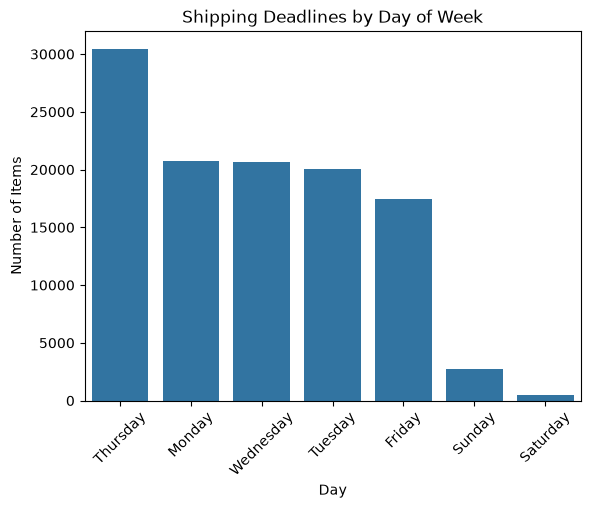

In [48]:
shipping_days = order_items["shipping_day"].value_counts()

sns.barplot(
    x=shipping_days.index,
    y=shipping_days.values
)

plt.xticks(rotation=45)
plt.title("Shipping Deadlines by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Items")
plt.savefig("../../output/charts/order_item/shipping_deadline_by_days_barplot",dpi=300)
plt.show()

In [35]:
order_items["shipping_hours"] = (order_items["shipping_limit_date"].dt.hour)

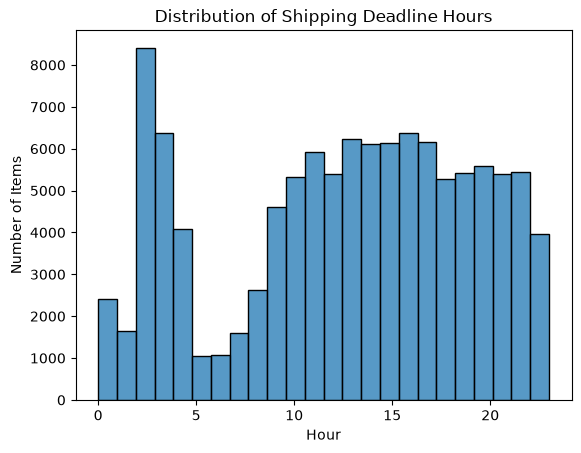

In [36]:

sns.histplot(data=order_items,
            x="shipping_hours",
            bins=24)

plt.title("Distribution of Shipping Deadline Hours")
plt.xlabel("Hour")
plt.ylabel("Number of Items")
plt.savefig("../../output/charts/order_item/shipping_by_hour_histplot",dpi=300)
plt.show()

## Key Observations

### 1. Product Price

- The **average product price** was approximately **120.65**.
- The minimum recorded product price was **0.85**, while the maximum was **6,735**.
- Products priced between **0 and 100** accounted for the largest share of orders, indicating that lower-priced products dominate the order-item distribution.

### 2. Freight Value

- The **average freight value** was approximately **19.99**.
- Freight charges ranged from **0** to **409.68**.
- The presence of zero freight charges suggests that some items were shipped without a recorded freight charge.

### 3. Relationship Between Product Price and Freight Value

- Product price and freight value show **no meaningful linear correlation**.
- The scatter plot exhibits a **heteroscedastic, funnel-shaped variance**, suggesting that the variability in freight value is not constant across different product prices.
- Overall, freight value appears to be **largely independent of product price**, indicating that factors other than product price may have a stronger influence on shipping costs.

### 4. Sellers and Orders

- The dataset contains **3,095 unique sellers**.
- There are approximately **109,555 order records** represented in the `order_items` dataset.
- The large number of sellers relative to orders indicates a broad seller base within the marketplace.

### 5. Number of Items per Order

- Most orders contain only **one item**.
- Approximately **87.5% of orders contain a single item**, indicating that multi-item orders are comparatively less common in this dataset.

### 6. Shipping Limit Date Range

The `shipping_limit_date` column spans a wide time period:

- **Minimum:** 2016-09-19 00:15:34
- **Maximum:** 2020-04-09 22:35:08

This indicates that the order-item data covers transactions and shipping deadlines across multiple years.

### 7. Orders by Year

The distribution of order items across years shows that **2018 recorded the highest number of orders**, followed by 2017.

| Year | Number of Orders |
|------|-----------------:|
| 2018 | 62,511 |
| 2017 | 49,765 |
| 2016 | 370 |
| 2020 | 4 |

The very small number of records in 2016 and 2020 suggests that the dataset is concentrated primarily around **2017–2018**.

### 8. Peak Months

Within the period with the highest activity, the following months recorded particularly high numbers of orders:

| Month | Number of Orders |
|-------|-----------------:|
| 2018-08 | 8,815 |
| 2018-05 | 8,765 |
| 2018-03 | 8,759 |

These months represent some of the strongest order activity observed in the dataset.

### 9. Shipping Deadline Time Distribution

The distribution of `shipping_limit_date` by hour appears to exhibit a **bimodal structure**, suggesting the presence of two distinct patterns:

- A **concentrated spike around 2–3 AM**, potentially indicating system-generated or batch-assigned shipping deadlines.
- A **broader distribution from approximately 9 AM to 10 PM**, which may correspond to deadlines generated during regular operating hours.

This suggests that shipping deadlines may be generated through **multiple processes rather than a single uniform mechanism**. Further investigation would be required to determine whether the early-morning spike is specifically caused by automated batch processing.